In [1]:
%pip install uproot

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 401.2/401.2 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 925.8/925.8 kB 47.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.3/689.3 kB 48.0 MB/s eta 0:00:00


In [2]:
%pip install awkward_pandas

**starting here**

In [8]:
import uproot
import numpy as np
import pandas as pd
import os


file = uproot.open("3merged.root")
os.makedirs("images", exist_ok=True)
tree = file["ThreeG_ScannerSCS"]

branches = [
    "EventID",
    "GammaIndex",
    "X_mm",
    "Y_mm",
    "EnergyDeposit_keV"
]

In [10]:
IMG_SIZE = 64

classes = {
    "ThreeG_NCS":0,
    "ThreeG_ScannerSCS":1,
    "ThreeG_ScannerDCS":2,
    "ThreeG_ScannerTCS":3,
    "ThreeG_MCS":4
}

labels = []
image_number = 0

for tree_name, label in classes.items():

    print(f"\nReading {tree_name}")

    tree = file[tree_name]

    for chunk in tree.iterate(
            branches,
            library="pd",
            step_size="20 MB"):

        print(f"Chunk with {len(chunk)} hits")

        for eventID, event in chunk.groupby("EventID"):

            image = np.zeros((IMG_SIZE, IMG_SIZE, 3),
                             dtype=np.float32)

            for gamma in [0,1,2]:

                g = event[event["GammaIndex"] == gamma]

                if len(g) == 0:
                    continue

                H, _, _ = np.histogram2d(

                    g["X_mm"],
                    g["Y_mm"],

                    bins=IMG_SIZE,

                    weights=g["EnergyDeposit_keV"]

                )

                image[:,:,gamma] = H

            np.save(

                f"images/event_{image_number}.npy",

                image

            )

            labels.append(label)

            image_number += 1

        del chunk

print(f"\nFinished!")
print(f"Images saved: {image_number}")


Reading ThreeG_NCS
Chunk with 70962 hits

Reading ThreeG_ScannerSCS
Chunk with 170168 hits

Reading ThreeG_ScannerDCS
Chunk with 110650 hits

Reading ThreeG_ScannerTCS
Chunk with 16170 hits

Reading ThreeG_MCS
Chunk with 498595 hits
Chunk with 354240 hits

Finished!
Images saved: 193841


In [11]:
labels = np.array(labels)

np.save("labels.npy", labels)

print(labels.shape)

(193841,)


In [27]:
import os
import numpy as np
from sklearn.model_selection import train_test_split

image_files = sorted(os.listdir("images"))
labels = np.load("labels.npy")

In [28]:
train_files, test_files, train_labels, test_labels = train_test_split(
    image_files,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

print(f"Training images: {len(train_files)}")
print(f"Testing images: {len(test_files)}")

Training images: 155072
Testing images: 38769


In [29]:
import tensorflow as tf

def load_image(filename, label):

    image = np.load(os.path.join("images", filename.decode()))

    return image.astype(np.float32), label

In [35]:
def map_func(filename, label):
    image, label = tf.numpy_function(
        load_image,
        [filename, label],
        [tf.float32, tf.int64]
    )
    # Ensure the shape of the tensors
    image = tf.ensure_shape(image, (IMG_SIZE, IMG_SIZE, 3))
    label = tf.ensure_shape(label, ())
    return image, label

train_dataset = tf.data.Dataset.from_tensor_slices(
    (train_files, train_labels)
)

train_dataset = train_dataset.map(map_func)

train_dataset = train_dataset.batch(32).prefetch(tf.data.AUTOTUNE)


test_dataset = tf.data.Dataset.from_tensor_slices(
    (test_files, test_labels)
)

test_dataset = test_dataset.map(map_func)

test_dataset = test_dataset.batch(32).prefetch(tf.data.AUTOTUNE)

In [36]:
model = tf.keras.Sequential([

    tf.keras.layers.Input(shape=(64,64,3)),

    tf.keras.layers.Conv2D(32,3,activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64,3,activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128,3,activation="relu"),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128,activation="relu"),

    tf.keras.layers.Dense(5,activation="softmax")

])

In [37]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [38]:
history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=10
)

Epoch 1/10
4846/4846 ━━━━━━━━━━━━━━━━━━━━ 249s 50ms/step - accuracy: 0.5835 - loss: 1.1430 - val_accuracy: 0.5852 - val_loss: 1.1403
Epoch 2/10
4846/4846 ━━━━━━━━━━━━━━━━━━━━ 246s 51ms/step - accuracy: 0.5850 - loss: 1.1164 - val_accuracy: 0.5847 - val_loss: 1.1167
Epoch 3/10
4846/4846 ━━━━━━━━━━━━━━━━━━━━ 244s 50ms/step - accuracy: 0.5861 - loss: 1.1095 - val_accuracy: 0.5843 - val_loss: 1.1148
Epoch 4/10
4846/4846 ━━━━━━━━━━━━━━━━━━━━ 229s 47ms/step - accuracy: 0.5888 - loss: 1.1006 - val_accuracy: 0.5824 - val_loss: 1.1234
Epoch 5/10
4846/4846 ━━━━━━━━━━━━━━━━━━━━ 223s 46ms/step - accuracy: 0.5937 - loss: 1.0904 - val_accuracy: 0.5786 - val_loss: 1.1438
Epoch 6/10
4846/4846 ━━━━━━━━━━━━━━━━━━━━ 229s 47ms/step - accuracy: 0.6002 - loss: 1.0771 - val_accuracy: 0.5770 - val_loss: 1.1578
Epoch 7/10
4846/4846 ━━━━━━━━━━━━━━━━━━━━ 227s 47ms/step - accuracy: 0.6055 - loss: 1.0649 - val_accuracy: 0.5725 - val_loss: 1.2348
Epoch 8/10
4846/4846 ━━━━━━━━━━━━━━━━━━━━ 230s 48ms/step - accuracy: 

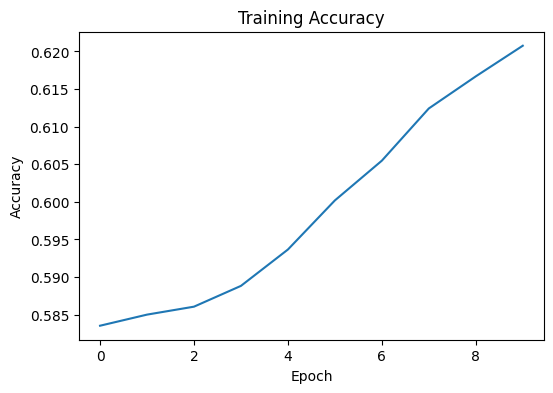

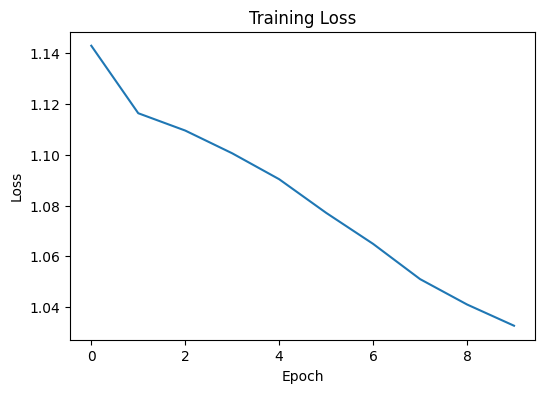

In [40]:
plt.figure(figsize=(6,4))
plt.plot(history.history["accuracy"])
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy")
plt.show()

plt.figure(figsize=(6,4))
plt.plot(history.history["loss"])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

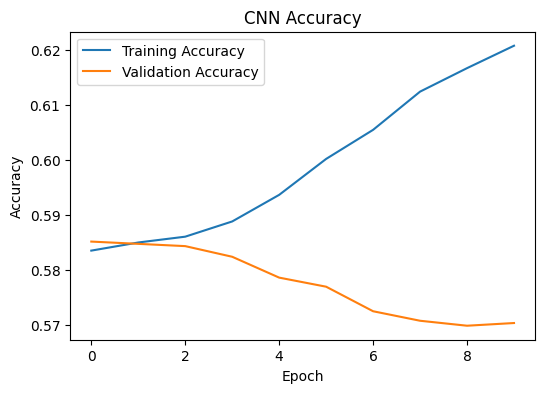

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Accuracy")
plt.legend()

plt.show()

In [41]:
model.save("three_gamma_classifier.keras")

In [42]:
model = tf.keras.models.load_model("three_gamma_classifier.keras")

In [43]:
image = np.load("images/event_0.npy")

prediction = model.predict(image[np.newaxis])

print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
[[0.10856514 0.18220112 0.09835587 0.01455981 0.59631807]]


In [44]:
class_names = [
    "NCS",
    "ScannerSCS",
    "ScannerDCS",
    "ScannerTCS",
    "MCS"
]

predicted = np.argmax(prediction)

print(class_names[predicted])

MCS
